# 03 — Model Comparison

Сравнение всех моделей по prediction CSV из `main.py`.

**Требуется**: сначала запустить `main.py`

In [1]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from thesis_app.notebook_helpers import apply_thesis_plot_style, preferred_xgb_label, best_ml_model_name, significance_stars, interpretation_text
apply_thesis_plot_style()


## Interpretation focus
Use this notebook to answer which models forecast intermarket dependency most reliably across assets and rolling windows. For the thesis text, emphasize consistency across experiments, not only the single best score.

In [2]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import sys, os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from thesis_app.pipeline import load_config, build_paths, metrics_to_latex

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

cfg   = load_config(os.path.join(ROOT, 'config.yaml'))
paths = build_paths(ROOT)
print('Predictions dir:', paths.predictions)


Predictions dir: D:\clear\outputs\predictions


In [3]:
# ── Load all prediction CSVs ─────────────────────────────────
csv_files = sorted(glob(os.path.join(paths.predictions, '*_predictions.csv')))
print(f'Found {len(csv_files)} prediction files')

experiments = {}
for f in csv_files:
    name = os.path.basename(f).replace('_predictions.csv', '')
    experiments[name] = pd.read_csv(f, index_col=0, parse_dates=True)

list(experiments.keys())


Found 24 prediction files


['corr_BTC-USD_ETH-USD_w14_fisher_z',
 'corr_BTC-USD_ETH-USD_w30_fisher_z',
 'corr_BTC-USD_ETH-USD_w60_fisher_z',
 'corr_BTC-USD_ETH-USD_w90_fisher_z',
 'corr_BTC-USD_GLD_w14_fisher_z',
 'corr_BTC-USD_GLD_w30_fisher_z',
 'corr_BTC-USD_GLD_w60_fisher_z',
 'corr_BTC-USD_GLD_w90_fisher_z',
 'corr_BTC-USD_SLV_w14_fisher_z',
 'corr_BTC-USD_SLV_w30_fisher_z',
 'corr_BTC-USD_SLV_w60_fisher_z',
 'corr_BTC-USD_SLV_w90_fisher_z',
 'corr_BTC-USD_UUP_w14_fisher_z',
 'corr_BTC-USD_UUP_w30_fisher_z',
 'corr_BTC-USD_UUP_w60_fisher_z',
 'corr_BTC-USD_UUP_w90_fisher_z',
 'corr_BTC-USD_^GSPC_w14_fisher_z',
 'corr_BTC-USD_^GSPC_w30_fisher_z',
 'corr_BTC-USD_^GSPC_w60_fisher_z',
 'corr_BTC-USD_^GSPC_w90_fisher_z',
 'corr_BTC-USD_^IXIC_w14_fisher_z',
 'corr_BTC-USD_^IXIC_w30_fisher_z',
 'corr_BTC-USD_^IXIC_w60_fisher_z',
 'corr_BTC-USD_^IXIC_w90_fisher_z']

In [4]:
# ── Metrics for all experiments ───────────────────────────────
rows = []
for key, df in experiments.items():
    y_true = df['y_true'].dropna()
    parts = key.split('_w')
    dep_part = parts[0]
    w_space_parts = parts[1].split('_', 1) if len(parts) > 1 else ['0', 'unknown']
    window = int(w_space_parts[0]) if w_space_parts[0].isdigit() else 0
    space = w_space_parts[1] if len(w_space_parts) > 1 else 'unknown'

    for model in [c for c in df.columns if c != 'y_true']:
        pred = df[model].dropna()
        common = y_true.index.intersection(pred.index)
        if len(common) < 50:
            continue
        yt = y_true.loc[common].values
        yp = pred.loc[common].values
        rows.append({
            'experiment': key, 'dependency': dep_part, 'window': window,
            'space': space, 'model': model,
            'MAE':  float(mean_absolute_error(yt, yp)),
            'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
            'R2':   float(r2_score(yt, yp)),
            'n':    len(common),
        })

metrics = pd.DataFrame(rows)
print(f'Total rows: {len(metrics)}')
metrics.head()


Total rows: 192


,experiment,dependency,window,space,model,MAE,RMSE,R2,n
0,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,Naive_Last,0.098419,0.157367,0.880122,2227
1,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,AR1,0.100796,0.155272,0.883294,2227
2,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,ElasticNet,0.146217,0.202477,0.801545,2227
3,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,Ridge,0.145460,0.201594,0.803273,2227
4,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,RF,0.155505,0.212911,0.780565,2227


In [5]:
# ── Best model per experiment ────────────────────────
BASELINES = ('Naive_Last', 'AR1', 'DCC_GARCH')
ML_MODELS = [m for m in metrics['model'].unique() if m not in BASELINES]
ml_metrics = metrics[metrics['model'].isin(ML_MODELS)]
best_per_exp = ml_metrics.loc[ml_metrics.groupby('experiment')['RMSE'].idxmin()]
print(best_per_exp[['dependency','window','model','RMSE','R2']].to_string(index=False))


          dependency  window      model     RMSE       R2
corr_BTC-USD_ETH-USD      14      Ridge 0.201594 0.803273
corr_BTC-USD_ETH-USD      30      Ridge 0.099851 0.924380
corr_BTC-USD_ETH-USD      60      Ridge 0.052363 0.970315
corr_BTC-USD_ETH-USD      90      Ridge 0.036502 0.981468
    corr_BTC-USD_GLD      14      Ridge 0.191651 0.740456
    corr_BTC-USD_GLD      30 ElasticNet 0.091673 0.875119
    corr_BTC-USD_GLD      60      Ridge 0.048110 0.940674
    corr_BTC-USD_GLD      90      Ridge 0.033048 0.961836
    corr_BTC-USD_SLV      14      Ridge 0.193698 0.719829
    corr_BTC-USD_SLV      30      Ridge 0.087554 0.881047
    corr_BTC-USD_SLV      60      Ridge 0.045457 0.944056
    corr_BTC-USD_SLV      90      Ridge 0.031594 0.962734
    corr_BTC-USD_UUP      14      Ridge 0.198216 0.767257
    corr_BTC-USD_UUP      30 ElasticNet 0.094353 0.890513
    corr_BTC-USD_UUP      60      Ridge 0.047693 0.948756
    corr_BTC-USD_UUP      90      Ridge 0.031784 0.968102
  corr_BTC-USD

RMSE table (corr_BTC-USD_^GSPC):
window          14      30      60      90
model                                     
AR1         0.1425  0.0646  0.0318  0.0220
DCC_GARCH   0.3287  0.1977  0.1285  0.1065
ElasticNet  0.1914  0.0897  0.0458  0.0328
GBM         0.2020  0.0987  0.0542  0.0394
Naive_Last  0.1446  0.0650  0.0318  0.0220
RF          0.2017  0.0975  0.0563  0.0380
Ridge       0.1910  0.0890  0.0448  0.0317
XGB_GPU     0.2079  0.1004  0.0564  0.0416


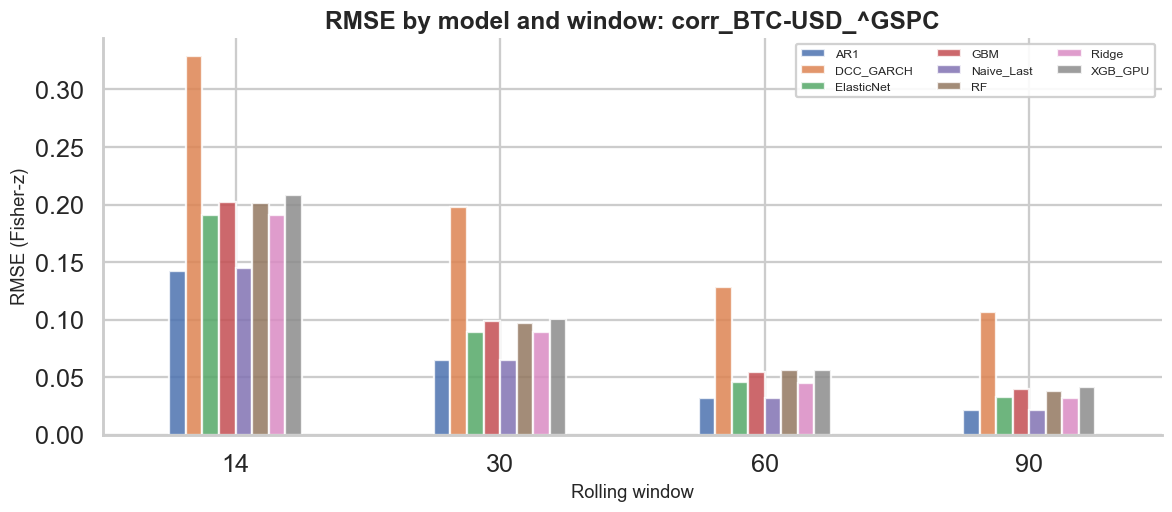

In [6]:
# ── RMSE comparison for one pair ───────────────────────────────
DEP = 'corr_BTC-USD_^GSPC'
sub = metrics[metrics['dependency'] == DEP].copy()
pivot = sub.pivot_table(index='model', columns='window', values='RMSE')
print(f'RMSE table ({DEP}):')
print(pivot.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
pivot.T.plot(kind='bar', ax=ax, alpha=0.85)
ax.set_title(f'RMSE by model and window: {DEP}')
ax.set_xlabel('Rolling window')
ax.set_ylabel('RMSE (Fisher-z)')
ax.legend(ncol=3, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, f'model_rmse_comparison.png'), dpi=130)
plt.show()


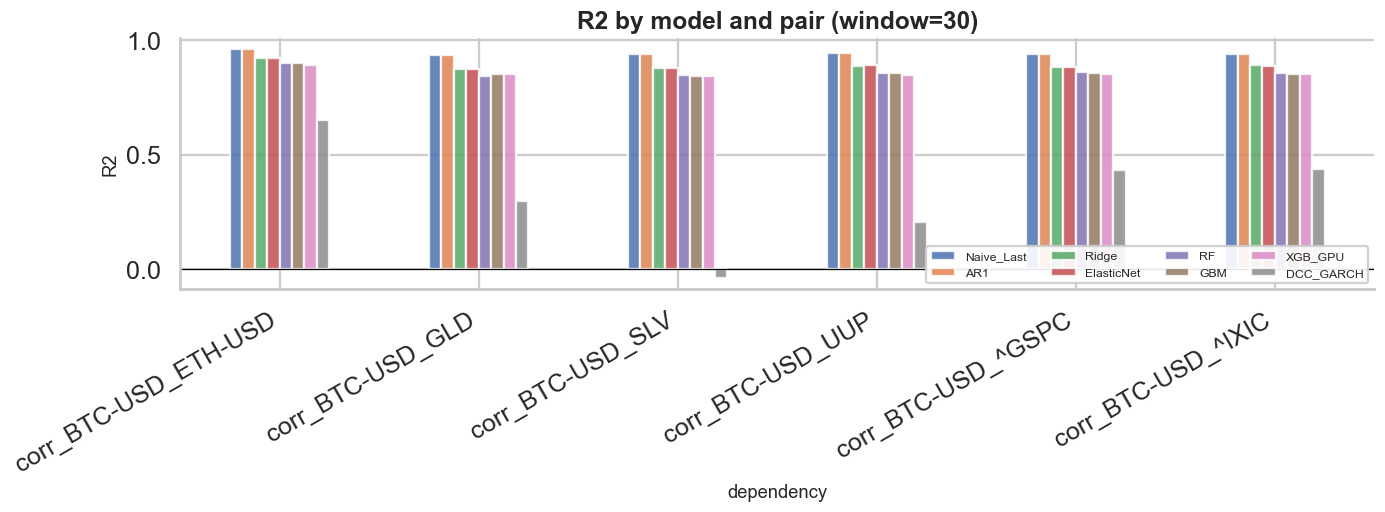

Interpretation: higher R2 indicates stronger practical usefulness in the out-of-sample setting.


In [7]:
# ── R2 comparison, window=30 ─────────────────────────────────────
W = 30
model_order = [m for m in ['Naive_Last', 'AR1', 'Ridge', 'ElasticNet', 'RF', 'GBM', 'XGB_GPU', 'XGB_CPU', 'DCC_GARCH'] if m in metrics['model'].unique()]
available = [m for m in model_order if m in metrics['model'].unique()]

sub30 = metrics[metrics['window'] == W].copy()
pivot_r2 = sub30.pivot_table(index='dependency', columns='model', values='R2')[available]

fig, ax = plt.subplots(figsize=(13, 5))
pivot_r2.plot(kind='bar', ax=ax, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'R2 by model and pair (window={W})')
ax.set_ylabel('R2')
ax.legend(ncol=4, fontsize=8, loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, f'model_r2_comparison_w{W}.png'), dpi=130)
plt.show()

print(interpretation_text('R2', higher_is_better=True))


In [8]:
# ── Overall ranking by mean RMSE ───────────────────────────────
ranking = metrics.groupby('model')[['RMSE','MAE','R2']].mean().sort_values('RMSE').round(4)
print('Mean metrics across all experiments:')
print(ranking.to_string())

metrics.to_csv(os.path.join(paths.results, 'metrics_all_models.csv'), index=False)
ranking.to_csv(os.path.join(paths.results, 'model_ranking.csv'))
print('Saved.')


Mean metrics across all experiments:
              RMSE     MAE      R2
model                             
AR1         0.0664  0.0404  0.9420
Naive_Last  0.0670  0.0395  0.9408
Ridge       0.0912  0.0634  0.8912
ElasticNet  0.0919  0.0642  0.8897
RF          0.1008  0.0709  0.8683
GBM         0.1014  0.0712  0.8669
XGB_GPU     0.1031  0.0733  0.8621
DCC_GARCH   0.2141  0.1681  0.3804
Saved.


     model  mean_improvement_%  n
     Ridge              -39.06 24
ElasticNet              -40.96 24
        RF              -60.28 24
       GBM              -61.73 24
   XGB_GPU              -64.62 24
 DCC_GARCH             -302.72 24


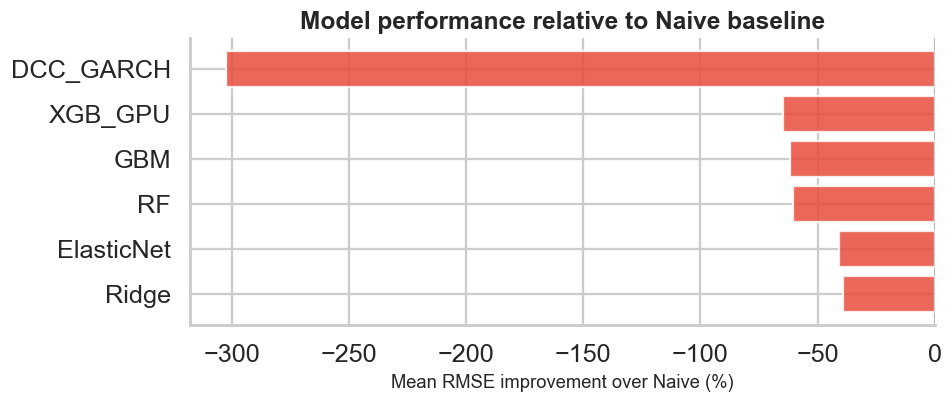

In [9]:
# ── Improvement over Naive baseline ─────────────────────────────────
naive_rmse = metrics[metrics['model'] == 'Naive_Last'].set_index('experiment')['RMSE']
improvement = []
for model in ML_MODELS + ['DCC_GARCH']:
    sub_m = metrics[metrics['model'] == model].set_index('experiment')
    common = sub_m.index.intersection(naive_rmse.index)
    if len(common) == 0:
        continue
    rel = ((naive_rmse[common] - sub_m.loc[common, 'RMSE']) / naive_rmse[common] * 100)
    improvement.append({'model': model, 'mean_improvement_%': rel.mean(), 'n': len(common)})

imp_df = pd.DataFrame(improvement).sort_values('mean_improvement_%', ascending=False)
print(imp_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in imp_df['mean_improvement_%']]
ax.barh(imp_df['model'], imp_df['mean_improvement_%'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean RMSE improvement over Naive (%)')
ax.set_title('Model performance relative to Naive baseline')
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'model_improvement_over_naive.png'), dpi=130)
plt.show()


In [10]:
# ── LaTeX table ───────────────────────────────────────────────────
metrics_for_latex = metrics.rename(columns={'space': 'target_space'}).copy()
metrics_for_latex['dependency'] = metrics_for_latex['dependency'].str.replace('corr_', '', regex=False)
tex_path = os.path.join(paths.tables, 'model_comparison_full.tex')
metrics_to_latex(
    metrics_for_latex.sort_values(['dependency', 'window', 'RMSE']).head(80),
    tex_path,
    caption='Out-of-sample forecasting metrics (Fisher-z space).',
    label='tab:model_comparison',
)
print(f'LaTeX saved: {tex_path}')
print('Model comparison complete.')


LaTeX saved: D:\clear\outputs\tables\model_comparison_full.tex
Model comparison complete.
